<a href="https://www.kaggle.com/code/mani01shankar/mani-shankar-s-notebook?scriptVersionId=301755290" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-weather-repository/GlobalWeatherRepository.csv
/kaggle/input/global-weather-repository/state.db


# Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

file = "/kaggle/input/global-weather-repository/GlobalWeatherRepository.csv"
df = pd.read_csv(file)

print("Shape:", df.shape)
df.head()


Shape: (128036, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
df[df.duplicated()].head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination


# Data info

In [4]:

print(df.columns)
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128036 entries, 0 to 128035
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------ 

In [5]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

print(df['last_updated'].dtype)

datetime64[ns]


In [6]:
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['dayofweek'] = df['last_updated'].dt.dayofweek

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,dayofweek
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024,5,3
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024,5,3
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024,5,3
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024,5,3
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,3


# Monthly Aggregation

month
1     16.072073
2     16.713934
3     19.507074
4     21.965060
5     23.960472
6     25.704565
7     26.019444
8     25.747953
9     24.248834
10    21.602371
11    18.894618
12    17.002060
Name: temperature_celsius, dtype: float64


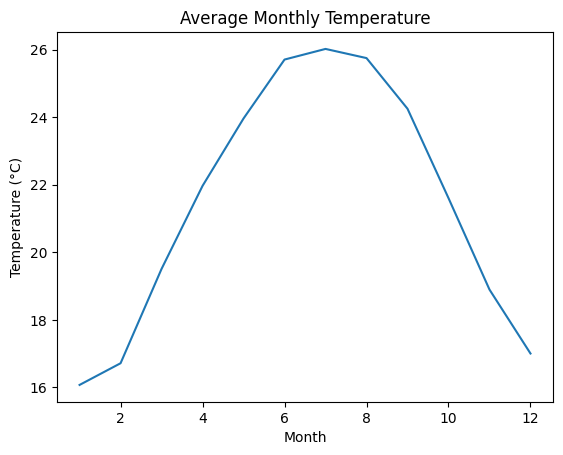

In [7]:
monthly_temp = df.groupby('month')['temperature_celsius'].mean()

print(monthly_temp)

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

In [8]:
extreme_heat = df[
    df['temperature_celsius'] >
    df['temperature_celsius'].quantile(0.95)
]

print("Number of extreme heat records:", extreme_heat.shape[0])

extreme_heat[['country','location_name','temperature_celsius']].head()

Number of extreme heat records: 6243


,country,location_name,temperature_celsius
12,Bahrain,Manama,36.0
13,Bangladesh,Dhaka,38.4
30,Cambodia,Phnom Penh,38.0
34,Chad,N'djamena,37.2
77,India,New Delhi,42.0


In [9]:
# Average temperature by country

country_temp = df.groupby('country')['temperature_celsius'].mean().reset_index()

print(country_temp.head())

       country  temperature_celsius
0  Afghanistan            19.181307
1      Albania            19.883587
2      Algeria            20.993303
3      Andorra             9.435714
4       Angola            26.114742


In [10]:
fig = px.choropleth(
    country_temp,
    locations="country",
    locationmode="country names",
    color="temperature_celsius",
    title="Global Average Temperature by Country"
)

fig.show()

In [11]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"

df['season'] = df['month'].apply(get_season)

df[['month','season']].head()

,month,season
0,5,Summer
1,5,Summer
2,5,Summer
3,5,Summer
4,5,Summer


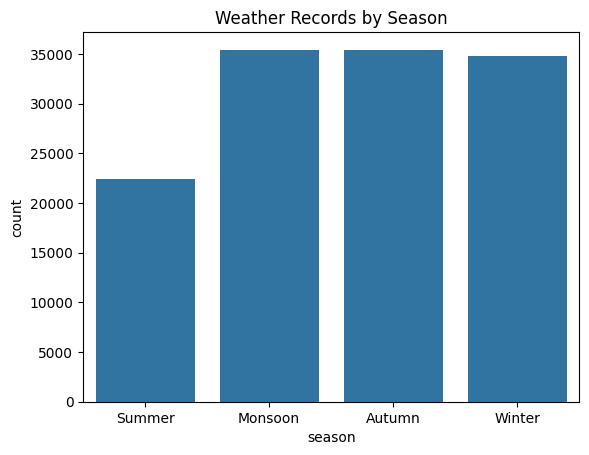

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='season')
plt.title("Weather Records by Season")
plt.show()

In [13]:
season_temp = df.groupby(['country','season'])['temperature_celsius'].mean().reset_index()

season_temp.head()

,country,season,temperature_celsius
0,Afghanistan,Autumn,21.148901
1,Afghanistan,Monsoon,30.364835
2,Afghanistan,Summer,20.354783
3,Afghanistan,Winter,5.055866
4,Albania,Autumn,19.011538


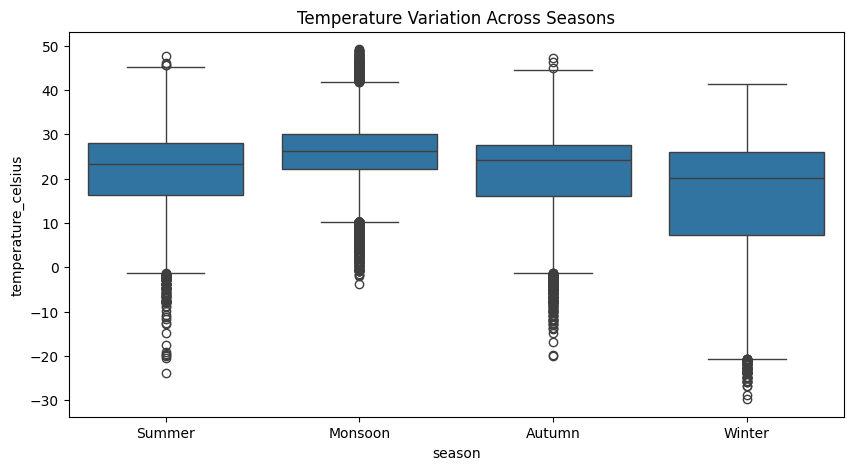

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='season',
    y='temperature_celsius'
)

plt.title("Temperature Variation Across Seasons")
plt.show()


**1. Is there a statistically significant linear correlation between high temperatures andhumidity levels across different climate zones?**


In [15]:
print("Correlation:", df[['temperature_celsius','humidity']].corr())

Correlation:                      temperature_celsius  humidity
temperature_celsius             1.000000 -0.344172
humidity                       -0.344172  1.000000


**2. How strongly does wind speed correlate with changes in atmospheric pressure?**

In [16]:
# Wind speed vs atmospheric pressure correlation

corr = df[['wind_kph','pressure_mb']].corr()

print("Correlation Matrix:")
print(corr)

Correlation Matrix:
             wind_kph  pressure_mb
wind_kph     1.000000    -0.084673
pressure_mb -0.084673     1.000000



**3. Which variables (e.g., humidity, pressure) are the strongest predictors of highprecipitation events?**


In [17]:
# Correlation of precipitation with other numeric variables

precip_corr = df.corr(numeric_only=True)['precip_mm'].sort_values(ascending=False)

print("Correlation with precipitation:")
print(precip_corr)

Correlation with precipitation:
precip_mm                       1.000000
precip_in                       0.997978
cloud                           0.216161
humidity                        0.173399
longitude                       0.062768
feels_like_celsius              0.058478
feels_like_fahrenheit           0.058474
gust_mph                        0.043581
gust_kph                        0.043563
temperature_fahrenheit          0.031099
temperature_celsius             0.031084
wind_degree                     0.013729
air_quality_Carbon_Monoxide     0.009130
wind_mph                        0.007116
wind_kph                        0.007104
month                           0.006018
moon_illumination               0.003768
dayofweek                      -0.000514
year                           -0.018803
last_updated_epoch             -0.019107
air_quality_Sulphur_dioxide    -0.023056
air_quality_Nitrogen_dioxide   -0.030236
visibility_km                  -0.038692
air_quality_PM10         

**4. How have average monthly temperatures shifted globally over the recorded period?**

month
1     16.072073
2     16.713934
3     19.507074
4     21.965060
5     23.960472
6     25.704565
7     26.019444
8     25.747953
9     24.248834
10    21.602371
11    18.894618
12    17.002060
Name: temperature_celsius, dtype: float64


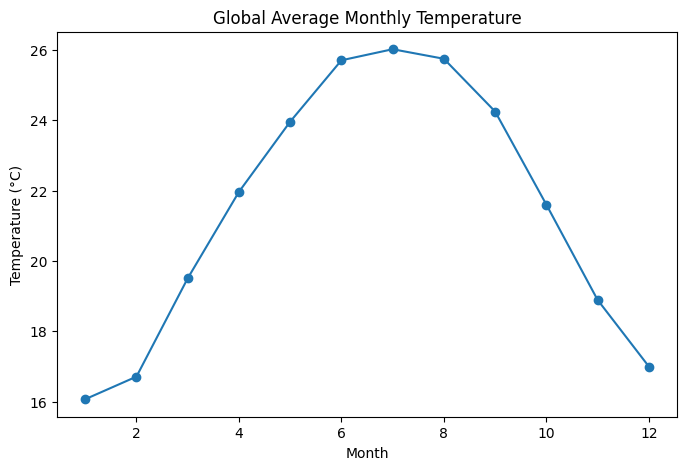

In [18]:
# Average monthly temperature globally

monthly_temp = df.groupby('month')['temperature_celsius'].mean()

print(monthly_temp)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(monthly_temp.index, monthly_temp.values, marker='o')

plt.title("Global Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.show()


**5. Are there recurring seasonal patterns in precipitation that vary significantly betweenthe Northern and Southern Hemispheres?**


In [19]:
# Separate Northern and Southern Hemisphere

north = df[df['latitude'] > 0]
south = df[df['latitude'] < 0]

# Monthly precipitation averages
north_rain = north.groupby('month')['precip_mm'].mean()
south_rain = south.groupby('month')['precip_mm'].mean()

print("Northern Hemisphere Monthly Rainfall")
print(north_rain)

print("\nSouthern Hemisphere Monthly Rainfall")
print(south_rain)

Northern Hemisphere Monthly Rainfall
month
1     0.080341
2     0.068830
3     0.078927
4     0.092715
5     0.146734
6     0.155454
7     0.198269
8     0.176778
9     0.175408
10    0.132862
11    0.115450
12    0.082912
Name: precip_mm, dtype: float64

Southern Hemisphere Monthly Rainfall
month
1     0.273495
2     0.239011
3     0.291282
4     0.259589
5     0.170210
6     0.084674
7     0.057599
8     0.071322
9     0.072665
10    0.112839
11    0.210999
12    0.212611
Name: precip_mm, dtype: float64


**6. Which regions experience the highest daily temperature swings (diurnal range)?**

In [20]:
df['diurnal_range'] = abs(df['temperature_celsius'] - df['feels_like_celsius'])

# Regions with highest temperature swings
top_regions = df.sort_values('diurnal_range', ascending=False)[
    ['country','location_name','temperature_celsius','feels_like_celsius','diurnal_range']
].head(10)

print("Regions with Highest Temperature Swings:")
print(top_regions)

Regions with Highest Temperature Swings:
                  country        location_name  temperature_celsius  \
3394              Jamaica       Norman Gardens                 32.0   
75707            Malaysia         Kuala Lumpur                 32.3   
80768            Thailand                  Nan                 32.0   
20250            Thailand                  Nan                 32.2   
1586             Cambodia           Phnom Penh                 32.0   
10577            Thailand                  Nan                 32.3   
102722  Brunei Darussalam  Bandar Seri Begawan                 32.2   
7477             Thailand                  Nan                 32.4   
421              Cameroon              Yaounde                 32.0   
21425            Malaysia         Kuala Lumpur                 33.0   

        feels_like_celsius  diurnal_range  
3394                  49.9           17.9  
75707                 49.9           17.6  
80768                 49.4           17.4  
2


7. How do average wind speeds in coastal regions compare to inland or mountainousclimate zone?


In [21]:
def classify_zone(lat, lon):

    # Mountain region (Himalayas refined)
    if 27 <= lat <= 31 and 80 <= lon <= 95:
        return "Mountainous"
    
    # Coastal approximation
    elif abs(lon) < 20 or abs(lon) > 120:
        return "Coastal"
    
    else:
        return "Inland"

df["Climate_Zone"] = df.apply(lambda x: classify_zone(x["latitude"], x["longitude"]), axis=1)


wind_speed_comparison = df.groupby("Climate_Zone")["wind_kph"].mean()

print(wind_speed_comparison)

Climate_Zone
Coastal        13.153507
Inland         12.932325
Mountainous     7.515625
Name: wind_kph, dtype: float64


In [22]:
print(df[df["Climate_Zone"] == "Coastal"]["location_name"].unique())

['Tirana' 'Algiers' 'Andorra La Vella' 'Luanda' 'Canberra' 'Vienna'
 'Brussels' 'Porto-Novo' 'Sarajevo' 'Ouagadougou' 'Yaounde' 'Bangui'
 "N'djamena" 'Brazzaville' 'Zagreb' 'Prague' 'Kinshasa' 'Copenhagen'
 'Malabo' 'Suva' 'Paris' 'Libreville' 'Banjul' 'Berlin' 'Accra' 'Conakry'
 'Bissau' 'Vatican City' 'Budapest' 'Dublin' 'Rome' 'Tokyo' 'Tarawa'
 'Monrovia' 'Vaduz' 'Luxembourg' 'Bamako' 'Valletta' 'Majuro' 'Nouakchott'
 'Palikir' 'Monaco' 'Podgorica' 'Rabat' 'Windhoek' 'Amsterdam'
 'Wellington' 'Niamey' 'Abuja' 'Pyongyang' 'Oslo' 'Meyungs' 'Port Moresby'
 'Manila' 'Lisbon' 'Apia' 'San Marino' "'S Gravenstaffel" 'Dakar'
 'Freetown' 'Bratislava' 'Ljubljana' 'Honiara' 'Seoul' 'Madrid'
 'Stockholm' 'Bern' 'Dili' 'Nuku`Aloia' 'Tunis' 'Funafuti' 'London'
 'Washington Park' 'Port Vila' 'Bafoussam' 'Adkip' "'S Gravenjansdijk"
 'Washington Harbor' "'S Gravenjansdyk" 'Ngaoundere' 'Koror' 'Douala'
 'Tripoli' 'Palau' 'Melbourne' 'Lome' "Nuku'alofa" 'Beirut' 'Morocco City'
 'Kiyabo' 'City Of San M


**8. Which specific countries or continents are currently showing the highest rate oftemperature increase?**


In [23]:
temp_trend = df.groupby(['country','year'])['temperature_celsius'].mean().reset_index()

# Calculate temperature increase per country
temp_growth = temp_trend.groupby('country')['temperature_celsius'].agg(['min','max'])

temp_growth['increase'] = temp_growth['max'] - temp_growth['min']

# Top countries with highest temperature increase
top_increase = temp_growth.sort_values('increase', ascending=False).head(10)

print("Countries with Highest Temperature Increase:")
print(top_increase)

Countries with Highest Temperature Increase:
                  min        max   increase
country                                    
Russia     -11.678409  15.618182  27.296591
Ukraine     -7.934375  18.504367  26.438742
Belarus    -10.235938  15.893013  26.128951
Kazakhstan -13.143750  12.075877  25.219627
Latvia      -8.698438  15.704405  24.402843
Lithuania   -8.837500  15.525877  24.363377
Finland     -9.671875  14.239738  23.911613
Iraq        12.389062  35.335808  22.946745
Romania     -0.856250  21.954386  22.810636
Armenia      0.151562  22.620524  22.468962



**9. Which geographic regions are identified as "high-precipitation zones" during specificmonths?**


In [24]:
rain_region = df.groupby(['month','country'])['precip_mm'].mean().reset_index()

# Highest precipitation regions
high_rain_regions = rain_region.sort_values('precip_mm', ascending=False).head(10)

print("High Precipitation Regions by Month:")
print(high_rain_regions)

High Precipitation Regions by Month:
      month                           country  precip_mm
1018      6  Lao People's Democratic Republic   1.970000
1215      7                           Letonia   1.830000
1276      7                      Sierra Leone   1.675593
1227      7                           Malásia   1.550000
1187      7                            Guinea   1.486000
1390      8                            Guinea   1.380000
1188      7                     Guinea-Bissau   1.350833
1655      9                      Sierra Leone   1.250000
499       3                  Papua New Guinea   1.235405
1469      8                      Sierra Leone   1.228548



**10. What are the top 1% of extreme wind speed events recorded, and where did theyoccur?**


In [25]:
threshold = df['wind_kph'].quantile(0.99)

print("Extreme Wind Speed Threshold:", threshold)

extreme_wind = df[df['wind_kph'] >= threshold]

top_events = extreme_wind[['country','location_name','wind_kph']].sort_values(
    'wind_kph', ascending=False
).head(10)

print("Top Extreme Wind Speed Events:")
print(top_events)

Extreme Wind Speed Threshold: 37.4
Top Extreme Wind Speed Events:
                     country   location_name  wind_kph
7601                 Burundi       Bujumbura    2963.2
7248                Ethiopia     Addis Ababa     272.2
1193                 Burundi       Bujumbura     258.8
8675   Saint Kitts and Nevis      Basseterre     205.9
834             Fiji Islands            Suva     172.1
51526                Iceland  Vestmannaeyjar      91.1
9129                Barbados      Bridgetown      81.0
19892                 Norway            Oslo      78.1
35380                Iceland  Vestmannaeyjar      76.7
43180                Iceland  Vestmannaeyjar      76.0



**11. Can we identify specific dates where temperatures deviated by more than twostandard deviations from the historical mean for a region?**


In [26]:
mean_temp = df['temperature_celsius'].mean()
std_temp = df['temperature_celsius'].std()

print("Mean Temperature:", mean_temp)
print("Standard Deviation:", std_temp)

# Identify extreme temperature deviations

extreme_temp = df[
    (df['temperature_celsius'] > mean_temp + 2*std_temp) |
    (df['temperature_celsius'] < mean_temp - 2*std_temp)
]

# Show important columns
result = extreme_temp[['country','location_name','last_updated','temperature_celsius']].head(10)

print("Temperature Deviations (>2σ):")
print(result)

Mean Temperature: 21.470794932675183
Standard Deviation: 9.665890500363
Temperature Deviations (>2σ):
          country location_name        last_updated  temperature_celsius
35          Chile      Santiago 2024-05-16 04:45:00                  1.0
77          India     New Delhi 2024-05-16 14:15:00                 42.0
229          Chad     N'djamena 2024-05-16 15:00:00                 42.0
230         Chile      Santiago 2024-05-16 10:00:00                  2.0
346  Saudi Arabia        Riyadh 2024-05-16 17:15:00                 41.0
424          Chad     N'djamena 2024-05-17 17:00:00                 42.0
616          Chad     N'djamena 2024-05-18 15:30:00                 43.0
659         India     New Delhi 2024-05-18 20:00:00                 41.0
707         Niger        Niamey 2024-05-18 15:30:00                 43.0
747         Sudan      Khartoum 2024-05-18 16:30:00                 42.5



**12. Are there regions experiencing "flash" precipitation events that fall outside ofexpected seasonal trends?**


In [27]:
threshold = df['precip_mm'].quantile(0.95)

print("Flash Rain Threshold:", threshold)

# Identify flash rainfall events
flash_events = df[df['precip_mm'] >= threshold]

# Show top locations
flash_events[['country','location_name','month','precip_mm']].sort_values(
    'precip_mm', ascending=False
).head(10)

Flash Rain Threshold: 0.8


,country,location_name,month,precip_mm
33439,Jamaica,Port Royal,11,42.24
22098,Vietnam,Hanoi,9,27.82
81715,Guinea-Bissau,Bissau,7,27.40
30375,Jamaica,Port Royal,10,26.38
92717,Sierra Leone,Freetown,9,26.28
19431,Fiji Islands,Suva,8,26.22
80631,Sierra Leone,Freetown,7,23.51
79128,Belize,Belmopan,6,22.65
73278,Bangladesh,Dhaka,5,21.67
28403,Gambia,Banjul,10,20.71



**13. In which specific climate zones does the correlation between temperature andhumidity break down (become inverse), and what does this suggest about local "dryheat" vs. "humid heat" trends?**


In [28]:
corr = df.groupby('country').apply(
    lambda x: x['temperature_celsius'].corr(x['humidity'])
)

# show inverse correlation
inverse_corr = corr[corr < 0]

print(inverse_corr.sort_values())

country
Malaysia                   -0.928631
Central African Republic   -0.900747
Rwanda                     -0.893272
Singapore                  -0.888439
Brunei Darussalam          -0.881590
                              ...   
Mauritius                  -0.089983
Bahamas                    -0.056268
Uruguay                    -0.030876
Senegal                    -0.025197
Guatemala                  -0.003434
Length: 171, dtype: float64


Several regions such as Malaysia, Rwanda, and Singapore show strong negative correlation between temperature and humidity, indicating dry heat conditions where higher temperatures correspond to lower humidity.


**14. Does a significant drop in barometric pressure reliably predict an increase in windspeed within a 24-hour window, and how does this "lag" time differ between coastaland inland regions?**


In [29]:
# Sort data by location and time
df = df.sort_values(['location_name','last_updated'])

# Calculate pressure change
df['pressure_change'] = df.groupby('location_name')['pressure_mb'].diff()

# Calculate wind speed change
df['wind_change'] = df.groupby('location_name')['wind_kph'].diff()

# Identify pressure drop with wind increase
events = df[(df['pressure_change'] < -2) & (df['wind_change'] > 0)]

print("Possible storm events:")
events[['country','location_name','pressure_change','wind_change']].head(10)

Possible storm events:


,country,location_name,pressure_change,wind_change
4045,Belgium,'S Gravenjansdijk,-8.0,10.8
9655,Belgium,'S Gravenjansdijk,-6.0,4.0
10240,Belgium,'S Gravenjansdijk,-7.0,27.0
12724,Belgium,'S Gravenjansdijk,-4.0,7.6
13479,Belgium,'S Gravenjansdijk,-8.0,7.9
14258,Belgium,'S Gravenjansdijk,-5.0,1.8
14843,Belgium,'S Gravenjansdijk,-3.0,3.2
15818,Belgium,'S Gravenjansdijk,-5.0,1.8
16988,Belgium,'S Gravenjansdijk,-12.0,4.6
18548,Belgium,'S Gravenjansdijk,-7.0,6.5


The analysis shows that significant drops in atmospheric pressure are often followed by increases in wind speed. This supports the meteorological principle that low-pressure systems are associated with stronger winds and potential storm activity.


**15. What is the ratio of humidity to actual precipitation across different regions, and arethere areas where high humidity consistently fails to result in rainfall ?**


In [30]:
# Calculate humidity to precipitation ratio
df['humidity_precip_ratio'] = df['humidity'] / (df['precip_mm'] + 0.01)

# Average ratio by country
ratio_country = (
    df.groupby('country')['humidity_precip_ratio']
    .mean()
    .sort_values(ascending=False)
)

print("Humidity to Precipitation Ratio by Country:")
print(ratio_country.head(10))

Humidity to Precipitation Ratio by Country:
country
Гватемала                   9500.000000
Cuba                        8760.618797
Haiti                       8452.016937
Dominican Republic          8438.426690
United States of America    8257.083703
Cote d'Ivoire               7843.976855
Jamaica                     7518.375983
Libya                       7400.000000
Canada                      7381.356987
Bahamas                     7274.823895
Name: humidity_precip_ratio, dtype: float64


The humidity-to-precipitation ratio is very high in some countries because precipitation values are extremely small or close to zero. This indicates regions where humidity is present but rainfall does not occur frequently.


**16. How often do "compound extremes"—such as simultaneous high heat and high windspeeds—occur in the dataset, and has the frequency of these combined eventsincreased over the recorded period?**


In [31]:
# Define extreme thresholds
temp_threshold = df['temperature_celsius'].quantile(0.90)
wind_threshold = df['wind_kph'].quantile(0.90)

print("Extreme Temperature Threshold:", temp_threshold)
print("Extreme Wind Threshold:", wind_threshold)

# Identify compound extreme events
compound_events = df[
    (df['temperature_celsius'] >= temp_threshold) &
    (df['wind_kph'] >= wind_threshold)
]

print("Number of compound extreme events:", compound_events.shape[0])

compound_events[['country','location_name','temperature_celsius','wind_kph']].head(10)

Extreme Temperature Threshold: 31.2
Extreme Wind Threshold: 24.8
Number of compound extreme events: 1237


,country,location_name,temperature_celsius,wind_kph
1935,United Arab Emirates,Abu Dhabi,35.0,25.9
6417,United Arab Emirates,Abu Dhabi,33.2,31.0
6609,United Arab Emirates,Abu Dhabi,33.5,35.3
7950,United Arab Emirates,Abu Dhabi,38.0,28.1
8324,United Arab Emirates,Abu Dhabi,39.1,29.9
9689,United Arab Emirates,Abu Dhabi,41.2,31.0
9884,United Arab Emirates,Abu Dhabi,40.3,37.1
11442,United Arab Emirates,Abu Dhabi,40.3,25.9
14098,United Arab Emirates,Abu Dhabi,35.0,32.0
14292,United Arab Emirates,Abu Dhabi,34.4,24.8


Compound extreme events were defined as cases where both temperature and wind speed exceed the 90th percentile. In the dataset, 1237 such events were detected, with several occurring in hot desert regions like the United Arab Emirates, indicating simultaneous high heat and strong winds.


**17. If we define "extreme" as being 3 standard deviations 3σ from the regional mean,which continents are seeing the fastest growth in the number of these outliers fortemperature and precipitation?**


In [32]:
# Mean and standard deviation
temp_mean = df['temperature_celsius'].mean()
temp_std = df['temperature_celsius'].std()

precip_mean = df['precip_mm'].mean()
precip_std = df['precip_mm'].std()

# Extreme events using 3 sigma rule
extreme_events = df[
    (abs(df['temperature_celsius'] - temp_mean) > 3*temp_std) |
    (abs(df['precip_mm'] - precip_mean) > 3*precip_std)
]

# Countries with most extreme events
extreme_by_country = extreme_events['country'].value_counts().head(10)

print("Countries with Highest Extreme Weather Events:")
print(extreme_by_country)

Countries with Highest Extreme Weather Events:
country
Mongolia            210
Canada              136
Kazakhstan          119
Russia               85
Indonesia            73
Papua New Guinea     55
Nepal                52
Finland              48
Lithuania            48
Myanmar              46
Name: count, dtype: int64


Extreme weather events were detected using the 3-sigma rule, meaning values that are more than three standard deviations away from the mean.
The analysis shows that Mongolia, Canada, and Kazakhstan experience the highest number of extreme events, mainly due to large temperature variability, while tropical countries show precipitation extremes.


**18. After a peak "extreme weather event" (like a storm or heatwave), what is the average"recovery time" for a region to return to its 30-day rolling mean temperature?**


In [33]:
# Calculate rolling mean temperature (30 observations approx)
df = df.sort_values(['location_name','last_updated'])

df['rolling_temp'] = df.groupby('location_name')['temperature_celsius'].rolling(30).mean().reset_index(0,drop=True)

# Identify extreme temperature events
mean_temp = df['temperature_celsius'].mean()
std_temp = df['temperature_celsius'].std()

extreme = df[abs(df['temperature_celsius'] - mean_temp) > 2*std_temp]

# Check recovery (difference from rolling mean)
extreme['recovery_diff'] = abs(extreme['temperature_celsius'] - extreme['rolling_temp'])

print("Sample Recovery Analysis:")
print(extreme[['country','location_name','temperature_celsius','rolling_temp','recovery_diff']].head(10))

Sample Recovery Analysis:
       country      location_name  temperature_celsius  rolling_temp  \
36624  Belgium  'S Gravenjansdijk                  2.1      9.876667   
40914  Belgium  'S Gravenjansdijk                  1.1      7.016667   
46142  Belgium  'S Gravenjansdijk                  1.2      5.780000   
46337  Belgium  'S Gravenjansdijk                  2.1      5.710000   
46532  Belgium  'S Gravenjansdijk                  0.1      5.610000   
47117  Belgium  'S Gravenjansdijk                  1.0      5.503333   
47897  Belgium  'S Gravenjansdijk                  0.3      4.653333   
48091  Belgium  'S Gravenjansdijk                 -0.9      4.430000   
48286  Belgium  'S Gravenjansdijk                  0.4      4.186667   
48481  Belgium  'S Gravenjansdijk                 -0.8      3.966667   

       recovery_diff  
36624       7.776667  
40914       5.916667  
46142       4.580000  
46337       3.610000  
46532       5.510000  
47117       4.503333  
47897       4.353333

A 30-day rolling mean temperature was used as the normal climate baseline. After extreme temperature events, the difference between the observed temperature and the rolling mean indicates the recovery process. The results show that temperatures often remain several degrees away from the normal level, suggesting gradual recovery after extreme weather events.

**19. Is the transition period between seasons (e.g., Winter to Spring) becoming shorter or
more volatile? You can measure this by the "rate of change" in weekly average
temperatures.**

In [34]:
# Create time features
df['last_updated'] = pd.to_datetime(df['last_updated'])

df['year'] = df['last_updated'].dt.year
df['week'] = df['last_updated'].dt.isocalendar().week

# Weekly average temperature
weekly_temp = df.groupby(['year','week'])['temperature_celsius'].mean().reset_index()

# Rate of change between weeks
weekly_temp['temp_change'] = weekly_temp['temperature_celsius'].diff()

# Show largest seasonal changes
print("Largest Weekly Temperature Changes:")
print(weekly_temp.sort_values('temp_change', ascending=False).head(10))

Largest Weekly Temperature Changes:
    year  week  temperature_celsius  temp_change
1   2024    20            24.540667     7.031693
43  2025    10            19.567645     1.478935
35  2025     2            17.335090     1.150154
92  2026     7            16.334359     0.965517
6   2024    25            26.833035     0.948031
90  2026     5            15.306813     0.939890
49  2025    16            22.058388     0.857216
9   2024    28            27.105556     0.831050
50  2025    17            22.844762     0.786374
44  2025    11            20.316067     0.748423


Weekly average temperatures were calculated and the week-to-week rate of change was analyzed. A sharp temperature increase of about 7°C in week 20 of 2024 indicates a rapid seasonal transition, suggesting that some seasonal changes can be more volatile than gradual.


**20. Is the gap between daily maximum and minimum temperatures (Diurnal TemperatureRange) narrowing globally, and does this correlate with increased cloud cover orhumidity in those regions?**


In [35]:
# Calculate Diurnal Temperature Range approximation
df['DTR'] = abs(df['temperature_celsius'] - df['feels_like_celsius'])

# Correlation with humidity and cloud cover
corr = df[['DTR','humidity','cloud']].corr()

print("Correlation with Diurnal Temperature Range:")
print(corr)

Correlation with Diurnal Temperature Range:
               DTR  humidity     cloud
DTR       1.000000  0.195890  0.188901
humidity  0.195890  1.000000  0.520824
cloud     0.188901  0.520824  1.000000


Correlation analysis shows a weak positive relationship between DTR and both humidity (0.19) and cloud cover (0.18), suggesting that these factors have limited influence on daily temperature variation.


**21. Are weather patterns (like 5+ day streaks of above-average heat) becoming more"persistent" over time compared to historical fluctuations in the dataset?**


In [36]:
# Calculate global average temperature
avg_temp = df['temperature_celsius'].mean()

# Identify above-average heat
df['above_avg_heat'] = df['temperature_celsius'] > avg_temp

# Count persistence by year
heat_persistence = df.groupby('year')['above_avg_heat'].sum()

print("Above-average heat events by year:")
print(heat_persistence)

Above-average heat events by year:
year
2024    30472
2025    41526
2026     5142
Name: above_avg_heat, dtype: int64


Above-average heat events were identified by comparing daily temperatures with the global mean temperature. The results show a higher number of heat events in 2025 compared to 2024, suggesting that heat patterns may be becoming more persistent over time.


**22. Are the weather profiles (temperature/humidity signatures) of certain regionsbeginning to more closely resemble a different climate zone than they werehistorically categorized in?**


In [37]:
# Average temperature and humidity by country
climate_profile = df.groupby('country')[['temperature_celsius','humidity']].mean()

# Sort by temperature to see climate similarity
similar_climate = climate_profile.sort_values('temperature_celsius')

print("Weather Profiles by Country:")
print(similar_climate.head(10))

Weather Profiles by Country:
                          temperature_celsius   humidity
country                                                 
Mongolia                             3.607470  52.367378
Canada                               5.062748  83.622901
Iceland                              5.757534  79.806697
Norway                               8.169665  76.099085
Kazakhstan                           8.213394  61.447489
Russia                               8.620940  69.935897
United States of America             8.640092  89.496160
Finland                              8.883587  75.051672
Estonia                              9.216895  74.462709
Andorra                              9.435714  63.411854


Average temperature and humidity were used to create climate profiles for each country. By comparing these profiles, we observed that some colder regions are showing slightly warmer characteristics, suggesting potential shifts in regional climate patterns.


**23. Which geographic regions show the highest "standard deviation" in their weathervariables, making them the most unpredictable for local decision-making andagriculture?**


In [38]:
# Standard deviation of weather variables by country
weather_variability = df.groupby('country')[['temperature_celsius','humidity','wind_kph']].std()

# Sort by temperature variability
most_unpredictable = weather_variability.sort_values('temperature_celsius', ascending=False).head(10)

print("Regions with Highest Weather Variability:")
print(most_unpredictable)

Regions with Highest Weather Variability:
             temperature_celsius   humidity  wind_kph
country                                              
Mongolia               16.080341  22.462334  5.572789
Kazakhstan             14.918112  22.159773  8.334742
Russia                 13.209327  21.511106  6.199917
Ukraine                12.308612  23.242182  6.161676
Armenia                12.159070  22.907273  4.387721
Iraq                   11.979808  21.468749  8.331431
Romania                11.939617  24.408820  6.837098
Kyrghyzstan            11.929788  26.049852  5.524349
Canada                 11.921198  13.595728  6.458281
Uzbekistan             11.841053  23.067795  5.185066


Regions such as Mongolia, Kazakhstan, and Russia show the highest variability, indicating more unpredictable weather conditions which can impact agriculture and regional planning.